# PCA: training distribution vs. prediction-folder documents

Loads a trained model's `ood_stats.npz` (the PCA-reduced training embeddings already computed at training time) and projects a folder of PDFs you want to predict into that same PCA space, using the exact `_project()` formula `src/ood.py` uses at inference time. Plots both together in 3D so you can see whether the prediction documents land inside or outside the training clusters.

**Edit the parameters cell below** (`MODEL_PATH`, `MODEL_KEY`, `PREDICT_FOLDER`) before running.

In [1]:
# The notebook's kernel doesn't start with the repo root on sys.path or as its working
# directory (unlike pytest, which gets sys.path via pythonpath = ["."] in pyproject.toml,
# and the CLI, which is always invoked from the repo root). Walk up from this notebook's
# location until pyproject.toml is found, then add it to sys.path AND chdir into it, so
# relative paths like Settings.default_model_path resolve the same way they do for the CLI.
import os
import sys
from pathlib import Path

_repo_root = Path.cwd().resolve()
while not (_repo_root / "pyproject.toml").exists():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
os.chdir(_repo_root)

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import torch
from sklearn.decomposition import PCA
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src.embeddings import LoadedModel, extract_embeddings
from src.ingestion.extract import extract_pdf_with_metadata
from src.ood import load_stats
from src.settings import Settings
from src.training.models import get_model_config
from src.training.tokenize import prepare_text

c:\Users\leona\source\repos\bert_tunning\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Parameters -- edit these for the model and documents you want to compare.
MODEL_PATH = Settings.default_model_path
MODEL_KEY = "beto"
PREDICT_FOLDER = Path("samples")
CHUNK_STRATEGY = Settings.CHUNK_STRATEGY
# The default model (BETO v2) was trained on this specific cache, not Settings.CACHE_PATH's
# generic default ("./data/bert_tunning_cache.parquet", which doesn't exist on disk) --
# see README.md's dataset summary table. Update this if MODEL_PATH points elsewhere.
CACHE_PATH = "./data/bert_tunning_cache_con_otro_300.parquet"
SEED = Settings.SEED  # must match the seed used for that training run, or the split won't match

In [4]:
# Training-side data: ood_stats.npz already stores every training document's embedding,
# reduced through the exact PCA fit at training time (src/ood.py::compute_class_stats).
stats = load_stats(Path(MODEL_PATH) / "ood_stats.npz")
train_embeddings = stats.knn_train_embeddings
train_labels = [stats.class_names[label_id] for label_id in stats.knn_train_labels]
len(train_embeddings), len(stats.class_names)

(1344, 9)

### Class distribution across train / val / test

One color per split, grouped side-by-side per class. `ood_stats.npz` only stores the train split, so val/test are reconstructed from `CACHE_PATH` via `make_split(seed=SEED)` -- the exact same call `src/training/pipeline.py` and the `compute-ood-stats`/`evaluate-ood-calibration` CLI commands use. `SEED` must match the one the model was actually trained with, or these won't reflect what the model saw.

In [5]:
from sklearn.preprocessing import LabelEncoder

from src.training.split import make_split

cache_df = pd.read_parquet(CACHE_PATH)
# make_split stratifies on label_id, which only exists after label-encoding -- the raw
# cache only has the string label column. Matches src/cli/_ood_common.py exactly.
cache_df["label_id"] = LabelEncoder().fit_transform(cache_df["label"])
_reconstructed_train_df, val_df, test_df = make_split(cache_df, seed=SEED)

split_counts = pd.concat(
    [
        pd.Series(train_labels).value_counts().rename("count").to_frame().assign(split="train"),
        val_df["label"].value_counts().rename("count").to_frame().assign(split="val"),
        test_df["label"].value_counts().rename("count").to_frame().assign(split="test"),
    ]
).reset_index(names="label")

class_order = split_counts[split_counts["split"] == "train"].sort_values("count", ascending=False)[
    "label"
]

fig_class_dist = px.bar(
    split_counts,
    x="label",
    y="count",
    color="split",
    barmode="group",
    category_orders={"label": class_order.tolist(), "split": ["train", "val", "test"]},
    color_discrete_map={"train": "indianred", "val": "steelblue", "test": "seagreen"},
    labels={"label": "Class", "count": "#Documents"},
    title=f"Class distribution across train / val / test ({len(cache_df)} total documents)",
)
fig_class_dist.update_layout(xaxis_tickangle=-35)
fig_class_dist.show()

In [6]:
# Prediction-side data: load the same base model, extract [CLS] embeddings for every
# PDF in PREDICT_FOLDER, then project them into the training run's PCA space with the
# identical formula BertTunningClassifier.predict_text uses at inference time.
model_cfg = get_model_config(MODEL_KEY)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
loaded = LoadedModel(model=model, tokenizer=tokenizer, device=device)

pdf_paths = sorted(PREDICT_FOLDER.glob("*.pdf"))
filenames = []
texts = []
for pdf_path in pdf_paths:
    extraction = extract_pdf_with_metadata(str(pdf_path))
    if extraction.text:
        filenames.append(pdf_path.name)
        texts.append(prepare_text(extraction.text, tokenizer, CHUNK_STRATEGY))

predict_raw_embeddings = extract_embeddings(loaded, texts, max_length=model_cfg.max_tokens)
predict_pca_embeddings = (predict_raw_embeddings - stats.pca_mean) @ stats.pca_components.T
len(filenames)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8730.17it/s]


6

In [7]:
# Both embedding sets now live in the same OOD_PCA_COMPONENTS-dimensional space (64 by
# default) -- too many dimensions to plot directly. Fit one more PCA on top, purely for
# 3D visualization; this second reduction has no bearing on the production thresholds.
viz_components = 3
combined = np.vstack([train_embeddings, predict_pca_embeddings])
viz = PCA(n_components=viz_components).fit_transform(combined)
train_viz = viz[: len(train_embeddings)]
predict_viz = viz[len(train_embeddings) :]

train_df = pd.DataFrame(
    {
        "x": train_viz[:, 0],
        "y": train_viz[:, 1],
        "z": train_viz[:, 2],
        "label": train_labels,
        "source": "train",
        "filename": "",
    }
)
predict_df = pd.DataFrame(
    {
        "x": predict_viz[:, 0],
        "y": predict_viz[:, 1],
        "z": predict_viz[:, 2],
        "label": "predict",
        "source": "predict",
        "filename": filenames,
    }
)
combined_df = pd.concat([train_df, predict_df], ignore_index=True)

In [8]:
fig = px.scatter_3d(
    combined_df,
    x="x",
    y="y",
    z="z",
    color="label",
    symbol="source",
    hover_data=["filename"],
    title=f"Training vs. prediction embeddings (PCA 3D) -- {MODEL_PATH}",
)
fig.update_traces(marker_size=4)
fig.show()

## Additional views of the OOD signals

The PCA scatter above shows spatial position, not the actual quantities `review_route` decides on. This section computes `mahalanobis_p_value`, `cosine_z`, and `knn_distance` for both the training set (leave-one-out, using each document's true label as its "predicted class" -- the same approximation `evaluate-ood-calibration` documents) and the prediction folder (via the real classifier, reusing the already-loaded model/tokenizer)."

In [9]:
from scipy.stats import chi2
from sklearn.metrics.pairwise import cosine_distances

from src.inference.classify import BertTunningClassifier


def reduced_space_signals(point: np.ndarray, predicted_label_id: int) -> tuple[float, float, float]:
    """mahalanobis_p / cosine_z / knn_distance for a point already in the training run's
    PCA-reduced space -- mirrors src/ood.py's math directly (skips _project(), since the
    point is already reduced) and src/inference/classify.py's is_out_of_distribution.
    Excludes an exact self-match (distance 0) from the k-NN neighbors, since the
    training set is being queried against itself here (leave-one-out).
    """
    diffs = stats.centroids - point
    maha_sq = np.einsum("kd,de,ke->k", diffs, stats.covariance_inv, diffs).min()
    maha_p = float(chi2.sf(maha_sq, df=stats.centroids.shape[1]))

    cosine_raw = float(cosine_distances(point.reshape(1, -1), stats.centroids).min())
    cosine_z = (cosine_raw - stats.cosine_calibration_mean) / stats.cosine_calibration_std

    labels_arr = np.array(stats.knn_train_labels)
    same_class = stats.knn_train_embeddings[labels_arr == predicted_label_id]
    distances = np.linalg.norm(same_class - point, axis=1)
    distances = distances[distances > 0]
    k_eff = min(Settings.OOD_KNN_NEIGHBORS, len(distances))
    if k_eff:
        knn_distance = float(np.partition(distances, k_eff - 1)[:k_eff].mean())
    else:
        knn_distance = float("nan")

    return maha_p, cosine_z, knn_distance


train_signal_rows = [
    reduced_space_signals(train_embeddings[i], stats.knn_train_labels[i])
    for i in range(len(train_embeddings))
]
train_maha_p, train_cosine_z, train_knn_distance = zip(*train_signal_rows, strict=True)

clf = BertTunningClassifier(MODEL_PATH, tokenizer=tokenizer, model=model)
predict_results = [clf.predict_text(t) for t in texts]

signals_df = pd.concat(
    [
        pd.DataFrame(
            {
                "mahalanobis_p": train_maha_p,
                "cosine_z": train_cosine_z,
                "knn_distance": train_knn_distance,
                "label": train_labels,
                "source": "train",
                "filename": "",
            }
        ),
        pd.DataFrame(
            {
                "mahalanobis_p": [r.mahalanobis_p_value for r in predict_results],
                "cosine_z": [r.cosine_z for r in predict_results],
                "knn_distance": [r.knn_distance for r in predict_results],
                "label": [r.label for r in predict_results],
                "source": "predict",
                "filename": filenames,
            }
        ),
    ],
    ignore_index=True,
)
# .tail() would only show the last 5 rows, silently cutting off the first prediction
# document whenever there are 6+ -- show every prediction row explicitly instead.
signals_df[signals_df["source"] == "predict"]

,mahalanobis_p,cosine_z,knn_distance,label,source,filename
1344,0.999447,-0.4011,2.1802,resolucion,predict,document_predict_1.pdf
1345,0.000000,6.4241,11.6622,decreto_ordenanza,predict,document_predict_2.pdf
1346,0.000000,5.5923,10.5472,decreto,predict,document_predict_3.pdf
1347,1.000000,-0.6750,0.8852,otro,predict,document_predict_4.pdf
1348,0.000000,6.5299,12.6801,boletines,predict,document_predict_5.pdf
1349,0.170770,-0.0678,3.3482,decreto_ordenanza,predict,document_predict_6.pdf


### 1. Threshold histograms -- the actual decision boundaries

Training-set distribution of each raw signal, with the calibrated threshold marked and prediction documents plotted as diamonds on the same axis. This shows directly whether a prediction crosses the line that drives `review_route`, which the spatial PCA view can't.

In [10]:
from plotly.subplots import make_subplots

signal_specs = [
    ("mahalanobis_p", Settings.OOD_MAHALANOBIS_P_THRESHOLD, "Mahalanobis p-value"),
    ("cosine_z", Settings.OOD_COSINE_THRESHOLD, "Cosine z-score"),
    ("knn_distance", Settings.OOD_KNN_DISTANCE_THRESHOLD, "k-NN mean distance"),
]
train_rows = signals_df[signals_df["source"] == "train"]
predict_rows = signals_df[signals_df["source"] == "predict"]

fig_hist = make_subplots(
    rows=1, cols=len(signal_specs), subplot_titles=[title for _, _, title in signal_specs]
)
for col, (column, threshold, _title) in enumerate(signal_specs, start=1):
    fig_hist.add_histogram(
        x=train_rows[column], name="train", marker_color="steelblue", row=1, col=col
    )
    fig_hist.add_scatter(
        x=predict_rows[column],
        y=[0] * len(predict_rows),
        mode="markers",
        marker={"color": "orangered", "size": 10, "symbol": "diamond"},
        name="predict",
        text=predict_rows["filename"],
        row=1,
        col=col,
    )
    fig_hist.add_vline(x=threshold, line_dash="dash", line_color="red", row=1, col=col)
fig_hist.update_layout(title="OOD signal distributions vs. calibrated thresholds", showlegend=False)
fig_hist.show()

### 2. Per-class box plot -- cluster heterogeneity

One box per training class for `knn_distance`, prediction documents overlaid as diamonds positioned at their *predicted* class. A wide box (e.g. a broad catch-all class) visually explains why Mahalanobis's shared-covariance assumption breaks down for that class -- see the k-NN detection note in README.md.

In [11]:
fig_box = px.box(
    train_rows,
    x="label",
    y="knn_distance",
    color="label",
    points="outliers",
    title="k-NN distance per class (training) vs. prediction documents",
)
fig_box.add_scatter(
    x=predict_rows["label"],
    y=predict_rows["knn_distance"],
    mode="markers",
    marker={"color": "black", "size": 12, "symbol": "diamond"},
    name="predict",
    text=predict_rows["filename"],
)
fig_box.show()

### 3. Parallel coordinates -- each document's full signal profile

One axis per signal, one line per document. `in_distribution=False` is an OR across the three signals, so a document can fail on just one axis -- this shows which one, for every document at once, instead of collapsing to a single accept/reject flag.

In [12]:
parallel_df = signals_df.copy()
parallel_df["is_predict"] = (parallel_df["source"] == "predict").astype(int)

fig_parallel = px.parallel_coordinates(
    parallel_df,
    dimensions=["mahalanobis_p", "cosine_z", "knn_distance"],
    color="is_predict",
    color_continuous_scale=["steelblue", "orangered"],
    title="OOD signal profile per document (parallel coordinates)",
)
fig_parallel.show()

### 4. Density contours -- actual class shape, not just point clouds

Reuses the 2D projection (`x`/`y`) from `combined_df` above. Contour lines make each class's real shape visible -- useful for seeing when a class is elongated or multi-modal rather than one coherent Gaussian blob, which is exactly the assumption Mahalanobis relies on.

In [13]:
train_2d = combined_df[combined_df["source"] == "train"]
predict_2d = combined_df[combined_df["source"] == "predict"]

fig_density = px.density_contour(
    train_2d,
    x="x",
    y="y",
    color="label",
    title="Training class shapes (PCA 2D density) vs. prediction documents",
)
fig_density.update_traces(contours_coloring="none")
fig_density.add_scatter(
    x=predict_2d["x"],
    y=predict_2d["y"],
    mode="markers",
    marker={"color": "black", "size": 10, "symbol": "diamond"},
    name="predict",
    text=predict_2d["filename"],
)
fig_density.show()

### 5. Reference-curve view -- each signal's own distribution shape

Same three signals as above, but drawn against their theoretical/empirical reference curve instead of a histogram: cosine z-score against the standard normal, Mahalanobis distance against its chi-squared tail (df = the real PCA-reduced dimensionality, `stats.centroids.shape[1]` -- not an illustrative placeholder), and k-NN distance as a per-document bar. Uses `predict_results` computed above -- no data is recomputed here.

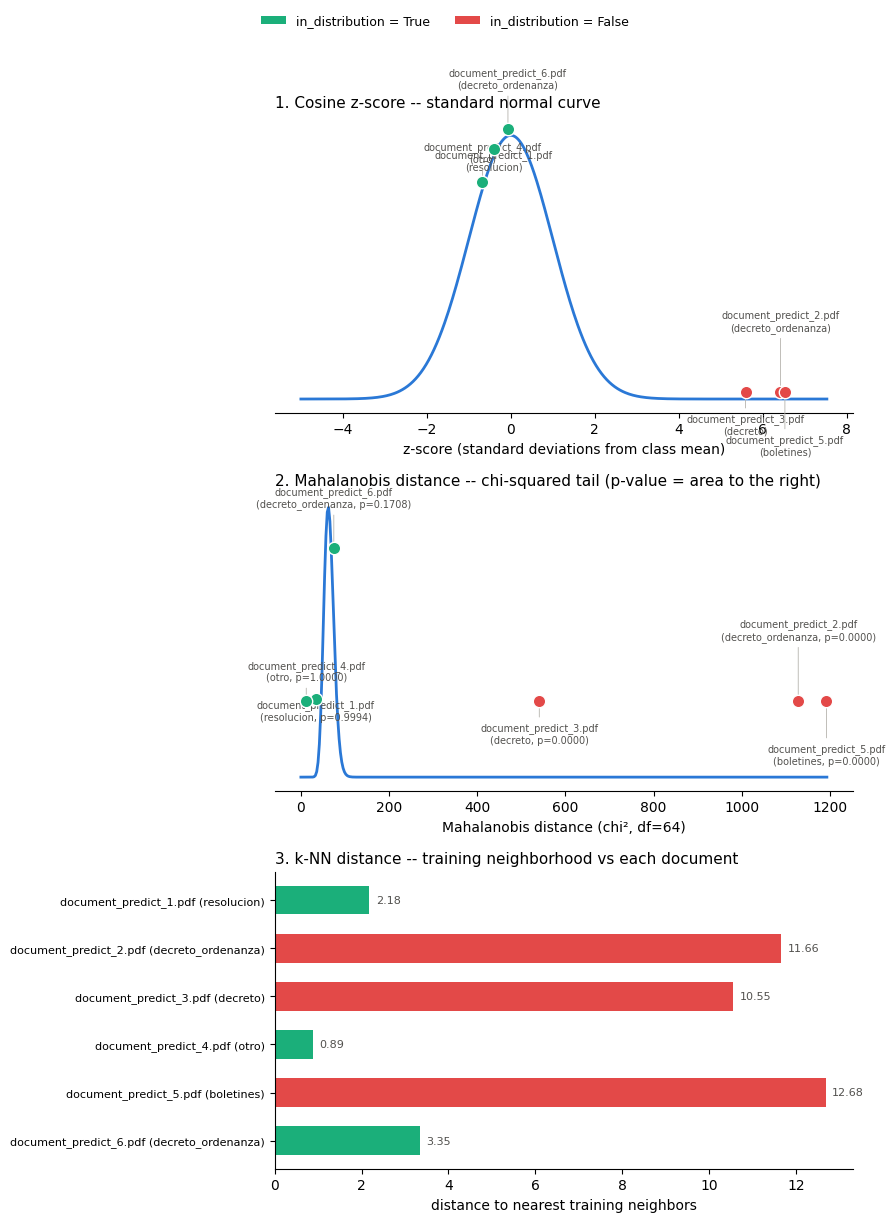

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import norm

from src.ood import mahalanobis_min_distance

OK_COLOR = "#1baf7a"
BAD_COLOR = "#e34948"
LINE_COLOR = "#2a78d6"

# The real PCA-reduced dimensionality this model's Mahalanobis distance was computed
# with (matches src/ood.py::mahalanobis_p_value's df argument) -- not an illustrative
# placeholder.
CHI2_DF = stats.centroids.shape[1]

# PredictResult.mahalanobis_p_value is rounded to 6 decimals in production -- several
# documents can round to exactly 0.0 and be indistinguishable if reconstructed via
# chi2.isf(p, df). Recompute the exact, un-rounded squared distance directly instead,
# straight from the pre-rounding math in src/ood.py, so every document gets its own
# real x-position instead of colliding with the others that also rounded to p=0.0.
exact_maha_distances = [mahalanobis_min_distance(e, stats) for e in predict_raw_embeddings]

ood_docs = [
    {
        "name": r.label,
        "filename": fname,
        "z": r.cosine_z,
        "p": r.mahalanobis_p_value,
        "maha_distance": maha_dist,
        "knn": r.knn_distance,
        "ok": bool(r.in_distribution),
    }
    for r, fname, maha_dist in zip(predict_results, filenames, exact_maha_distances, strict=True)
]


def _staggered_offsets(values: list[float]) -> list[int]:
    """Assign vertical label offsets by proximity rank, not original order, so points
    that land close together on the x-axis (e.g. several documents all flagged
    anomalous) get alternating up/down offsets instead of stacking their labels."""
    pattern = [15, -15, 30, -30, 45, -45, 60, -60]
    order = sorted(range(len(values)), key=lambda i: values[i])
    offsets = [0] * len(values)
    for rank, i in enumerate(order):
        offsets[i] = pattern[rank % len(pattern)]
    return offsets


def plot_cosine_zscore(ax: plt.Axes, docs: list[dict]) -> None:
    """Chart 1 -- standard normal curve with each doc's z-score plotted."""
    z_values = [d["z"] for d in docs]
    x = np.linspace(min([*z_values, -4]) - 1, max([*z_values, 4]) + 1, 400)
    ax.plot(x, norm.pdf(x), color=LINE_COLOR, linewidth=2)

    offsets = _staggered_offsets(z_values)
    for d, off in zip(docs, offsets, strict=True):
        color = OK_COLOR if d["ok"] else BAD_COLOR
        y_pt = norm.pdf(d["z"]) + 0.01
        ax.scatter(d["z"], y_pt, color=color, s=80, edgecolors="white", linewidths=1, zorder=5)
        ax.annotate(
            f"{d['filename']}\n({d['name']})",
            (d["z"], y_pt),
            textcoords="offset points",
            xytext=(0, off),
            fontsize=7,
            ha="center",
            color="#52514e",
            arrowprops={"arrowstyle": "-", "color": "#b5b3ad", "linewidth": 0.6},
        )

    ax.set_xlabel("z-score (standard deviations from class mean)")
    ax.set_yticks([])
    ax.set_title("1. Cosine z-score -- standard normal curve", fontsize=11, loc="left")
    ax.spines[["top", "right", "left"]].set_visible(False)


def plot_mahalanobis_chi2(ax: plt.Axes, docs: list[dict], df: int) -> None:
    """Chart 2 -- chi-squared curve with each doc's exact Mahalanobis distance."""
    distances = [d["maha_distance"] for d in docs]
    x = np.linspace(0.01, max([*distances, chi2.ppf(0.99, df)]) + 1, 400)
    ax.plot(x, chi2.pdf(x, df), color=LINE_COLOR, linewidth=2)

    offsets = _staggered_offsets(distances)
    for d, off in zip(docs, offsets, strict=True):
        color = OK_COLOR if d["ok"] else BAD_COLOR
        y_pt = chi2.pdf(d["maha_distance"], df) + 0.01
        ax.scatter(
            d["maha_distance"], y_pt, color=color, s=80, edgecolors="white", linewidths=1, zorder=5
        )
        ax.annotate(
            f"{d['filename']}\n({d['name']}, p={d['p']:.4f})",
            (d["maha_distance"], y_pt),
            textcoords="offset points",
            xytext=(0, off),
            fontsize=7,
            ha="center",
            color="#52514e",
            arrowprops={"arrowstyle": "-", "color": "#b5b3ad", "linewidth": 0.6},
        )

    ax.set_xlabel(f"Mahalanobis distance (chi², df={df})")
    ax.set_yticks([])
    ax.set_title(
        "2. Mahalanobis distance -- chi-squared tail (p-value = area to the right)",
        fontsize=11,
        loc="left",
    )
    ax.spines[["top", "right", "left"]].set_visible(False)


def plot_knn_distance(ax: plt.Axes, docs: list[dict]) -> None:
    """Chart 3 -- horizontal bar chart of k-NN distance per document."""
    labels = [f"{d['filename']} ({d['name']})" for d in docs]
    knn_vals = [d["knn"] for d in docs]
    colors = [OK_COLOR if d["ok"] else BAD_COLOR for d in docs]

    y_pos = np.arange(len(labels))
    ax.barh(y_pos, knn_vals, color=colors, height=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("distance to nearest training neighbors")
    ax.set_title(
        "3. k-NN distance -- training neighborhood vs each document", fontsize=11, loc="left"
    )
    ax.spines[["top", "right"]].set_visible(False)

    for i, v in enumerate(knn_vals):
        ax.text(v + 0.15, i, f"{v:.2f}", va="center", fontsize=8, color="#52514e")


fig, axes = plt.subplots(3, 1, figsize=(9, 12))
fig.patch.set_facecolor("white")

plot_cosine_zscore(axes[0], ood_docs)
plot_mahalanobis_chi2(axes[1], ood_docs, CHI2_DF)
plot_knn_distance(axes[2], ood_docs)

legend_elements = [
    Patch(facecolor=OK_COLOR, label="in_distribution = True"),
    Patch(facecolor=BAD_COLOR, label="in_distribution = False"),
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9,
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 6. Does the training set actually look Gaussian? (QQ-plot)

The chi²-based `mahalanobis_p_value` assumes class-conditional embeddings are multivariate Gaussian with one shared covariance matrix. If `X ~ N(mu, Sigma)`, then `(X-mu)ᵀ Sigma⁻¹ (X-mu) ~ chi²(df)` -- so sorting the *training set's own* squared Mahalanobis distances and plotting them against the theoretical chi²(df) quantiles is the standard empirical check for whether that assumption actually holds. Points on the diagonal = good fit; points bowing away (especially in the tail) = the assumption is violated there, which is the likely explanation for the 20-30% empirical false-positive rate `evaluate-ood-calibration` already measured for this signal.

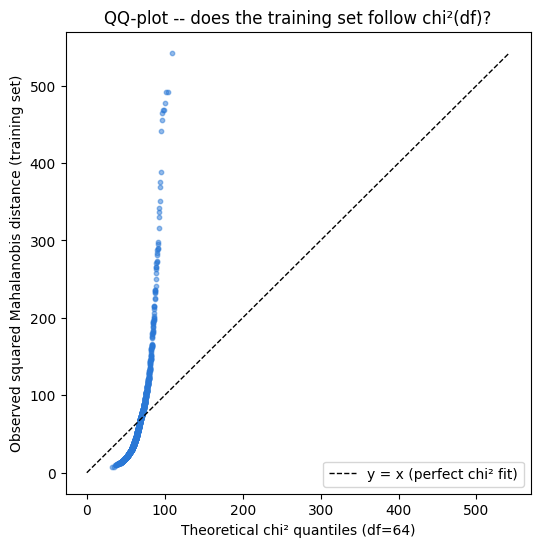

In [15]:
train_maha_sq = []
for point in train_embeddings:
    diffs = stats.centroids - point
    train_maha_sq.append(np.einsum("kd,de,ke->k", diffs, stats.covariance_inv, diffs).min())

observed = np.sort(train_maha_sq)
n_obs = len(observed)
theoretical = chi2.ppf((np.arange(1, n_obs + 1) - 0.5) / n_obs, CHI2_DF)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(theoretical, observed, s=10, alpha=0.5, color=LINE_COLOR)
diag = [0, max(theoretical.max(), observed.max())]
ax.plot(diag, diag, color="black", linewidth=1, linestyle="--", label="y = x (perfect chi² fit)")
ax.set_xlabel(f"Theoretical chi² quantiles (df={CHI2_DF})")
ax.set_ylabel("Observed squared Mahalanobis distance (training set)")
ax.set_title("QQ-plot -- does the training set follow chi²(df)?")
ax.legend()
plt.show()